open balanced dataset and start set up tokenizer

In [86]:
import pandas as pd
import torch
from datasets import load_dataset,ClassLabel, Dataset

from transformers import Trainer

In [87]:
#from google.colab import drive
#drive.mount("/content/drive")

In [88]:
dataset = load_dataset("csv", data_files="/content/drive/MyDrive/lyricsclassificationdata/archive/balancedSubset10kRockJazzClassicalHipHop.csv")

Generating train split: 0 examples [00:00, ? examples/s]

In [89]:
genres = list(set(dataset["train"]["genre"]))
class_label = ClassLabel(names=genres)
dataset = dataset["train"].cast_column("genre", class_label)

Casting the dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [90]:
dataset_split : Dataset = dataset.train_test_split(test_size=0.2, seed=69, stratify_by_column="genre")

In [91]:
from transformers import AutoTokenizer

In [92]:

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

LITTLE SETUP

In [93]:
def tokenize_function (set : Dataset) :
    return tokenizer(set['lyrics'], padding="max_length", truncation=True,max_length=512)

In [94]:
tokenized_dataset = dataset_split.map(tokenize_function, batched=True)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [95]:
tokenized_dataset = tokenized_dataset.rename_column("genre", "labels")

In [96]:
from transformers import AutoModelForSequenceClassification

In [97]:

model_name = "bert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [98]:
#!pip install evaluate
import numpy as np
from evaluate import load

In [99]:


metric_f1 = load("f1")
metric_acc = load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": metric_acc.compute(
            predictions=preds,
            references=labels
        )["accuracy"],

        "f1_macro": metric_f1.compute(
            predictions=preds,
            references=labels,
            average="macro"  
        )["f1"],
    }

In [100]:
from transformers import TrainingArguments,EarlyStoppingCallback

In [101]:


#look at medium article for this 

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",       
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    label_smoothing_factor=0.05,
    logging_dir="./logs",
    logging_steps=100,

    fp16=True,
)

print(training_args)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [102]:
trainer = Trainer(
    model=model,                        
    args=training_args,                 
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],   
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


In [103]:

trainer.train()
trainer.save_model("models/model10kRockJazzClassicalHipHop")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.798520,0.796883,0.705500,0.700374
2,0.677964,0.786597,0.737000,0.737487
3,0.540083,0.809346,0.740500,0.742377


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [104]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

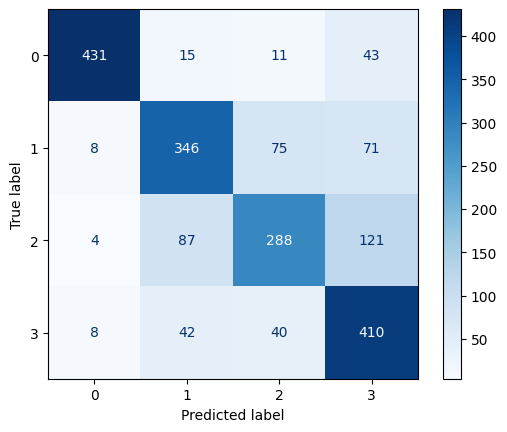

[[431  15  11  43]
 [  8 346  75  71]
 [  4  87 288 121]
 [  8  42  40 410]]


In [105]:
#confusion matrix to see to understand why model is so shit

predictions = trainer.predict(tokenized_dataset['test'])

logits = predictions.predictions
labels = predictions.label_ids

preds = np.argmax(logits, axis=-1)

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

print(cm)